# Notebook de coclustering de clients i productes

Aquest notebook aplica tècniques de coclustering per analitzar la matriu de compres client-producte.  
L’objectiu és descobrir grups creuats de clients i productes que comparteixen patrons de compra, per generar coneixement útil per a màrqueting.  
S’hi inclouen visualitzacions i exportació dels resultats en format CSV.


# Construcció de la matriu client-producte i aplicació de coclustering

Es construeix una matriu binària on cada fila representa un client i cada columna un producte. La cel·la conté 1 si el client ha comprat el producte, i 0 en cas contrari.  
Per evitar soroll, s’eliminen els clients amb molt poques compres i els productes molt poc venuts.  
Un cop preparada la matriu, s’aplica l’algorisme de **Spectral CoClustering**, que agrupa simultàniament clients i productes segons patrons compartits.  
Els resultats es guarden i es reordena la matriu per visualitzar millor els coclústers detectats.


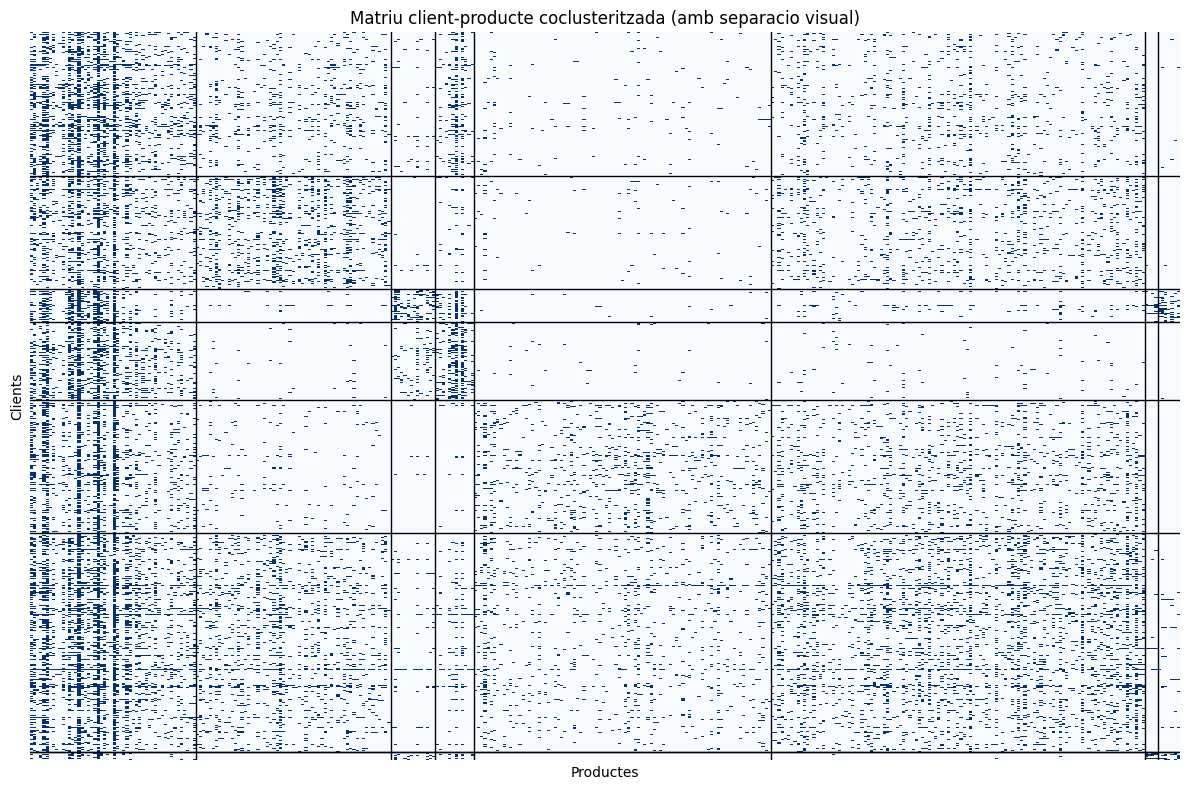

In [11]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Carreguem el dataset ja preparat
df = pd.read_csv("../data/df_preparat.csv")

# Construim la matriu binaria client-producte a partir de les compres realitzades
matriu_client_producte = pd.crosstab(df["CustomerID"], df["Product_Description"])
matriu_client_producte = (matriu_client_producte > 0).astype(int)

# Filtratge de clients i productes amb activitat minima
matriu_filtrada = matriu_client_producte.loc[
    matriu_client_producte.sum(axis=1) >= 5,
    matriu_client_producte.sum(axis=0) >= 10
]

# Apliquem l'algoritme Spectral CoClustering per descobrir grups de clients i productes relacionats
n_clusters = 8
model = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model.fit(matriu_filtrada)

# Assignem etiquetes de cluster als clients i als productes
matriu_filtrada["Client_Cluster"] = model.row_labels_

clusters_productes = pd.DataFrame({
    "Product_Description": matriu_filtrada.columns[:-1],  # excloem la columna de clusters
    "Cluster_Producte": model.column_labels_
})

# Exportem els resultats a CSV per a ús posterior
matriu_filtrada.reset_index().to_csv("../filesRunTime/client_coclusters.csv", index=False)
clusters_productes.to_csv("../filesRunTime/product_coclusters.csv", index=False)

# Reordenem la matriu per visualitzar millor els coclusters formats
matriu_reordenada = matriu_filtrada.drop("Client_Cluster", axis=1).iloc[
    model.row_labels_.argsort(),
    model.column_labels_.argsort()
]

# Calculem les posicions on canvien els coclusters per traçar les divisions visuals
row_ticks = np.cumsum(np.bincount(model.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model.column_labels_))[:-1]

# Visualitzem la matriu coclusteritzada amb separacions i escala de color
plt.figure(figsize=(12, 8))
ax = sns.heatmap(matriu_reordenada, cmap="Blues", cbar=False, xticklabels=False, yticklabels=False)

for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)

plt.title("Matriu client-producte coclusteritzada (amb separacio visual)")
plt.xlabel("Productes")
plt.ylabel("Clients")
plt.tight_layout()
plt.show()


# Identificació de productes rellevants per a cada grup de clients

Per a cada clúster de clients obtingut amb coclustering, s’analitzen tots els clústers de productes i es calcula la densitat d’interaccions entre els dos grups.  
S’identifiquen aquells clústers de productes amb **densitat superior al llindar** (calculat amb mitjana + desviació).  
A continuació, es recullen els productes associats i es guarden en fitxers CSV com a suggeriments de perfil per a cada grup de clients.


In [12]:
# Llistem les columnes que representen els productes (excloem la columna que indica el cluster del client)
columnes_productes = [col for col in matriu_filtrada.columns if col != "Client_Cluster"]

# Iterem per cada cluster de clients identificat pel model de coclustering
for id_cluster_client in range(n_clusters):
    # Seleccionem els clients que pertanyen al cluster actual
    idx_clients = matriu_filtrada.index[model.row_labels_ == id_cluster_client]

    # Guardarem les densitats dels blocs client-producte per cada cluster de productes
    densitats_cluster = []

    # Iterem per cada cluster de productes
    for j in range(n_clusters):
        # Obtenim les columnes de productes que pertanyen al cluster j
        idx_productes = [col for k, col in enumerate(columnes_productes) if model.column_labels_[k] == j]

        # Bloc de la matriu amb les compres dels clients del cluster i els productes del cluster actual
        bloc = matriu_filtrada.loc[idx_clients, idx_productes]

        # Si el bloc està buit (cap client ha comprat cap producte del grup), el saltem
        if bloc.size == 0:
            continue

        # Calculem la densitat com la proporció de compres realitzades respecte al total de cel·les del bloc
        densitat = bloc.values.sum() / bloc.size
        densitats_cluster.append({
            "Cluster_Producte": j,
            "Densitat": round(densitat, 4),
            "Num_Clients": len(idx_clients),
            "Num_Productes": len(idx_productes)
        })

    # Convertim la llista de densitats a un DataFrame per fer-ne anàlisi estadística
    df_densitat = pd.DataFrame(densitats_cluster)

    # Calculem la mitjana i desviació estàndard de les densitats per establir un llindar de rellevància
    mitjana_densitat = df_densitat["Densitat"].mean()
    desviacio_densitat = df_densitat["Densitat"].std()
    llindar = mitjana_densitat + 0.5 * desviacio_densitat

    # Considerem rellevants els clusters de productes amb una densitat superior al llindar
    clusters_relevants = df_densitat[df_densitat["Densitat"] >= llindar]["Cluster_Producte"].tolist()

    # Llistem tots els productes que pertanyen als clusters seleccionats
    productes_relevants = [
        col for i, col in enumerate(columnes_productes)
        if model.column_labels_[i] in clusters_relevants
    ]

    # Si hi ha productes rellevants, els exportem en un fitxer CSV per a ús posterior
    if productes_relevants:
        df_resultat = pd.DataFrame({"Product_Description": productes_relevants})
        df_resultat.to_csv(f"../filesRunTime/products_relevant_for_client_cluster_{id_cluster_client}.csv", index=False)
        print(f"✅ Client cluster {id_cluster_client} → product clusters {clusters_relevants} → {len(productes_relevants)} productes exportats.")
    else:
        # Si cap cluster de productes supera el llindar, ho notifiquem per consola
        print(f"ℹ️ Client cluster {id_cluster_client} → cap cluster de productes supera el llindar.")


✅ Client cluster 0 → product clusters [0, 3] → 64 productes exportats.
✅ Client cluster 1 → product clusters [0, 1] → 113 productes exportats.
✅ Client cluster 2 → product clusters [0, 2, 3, 7] → 85 productes exportats.
✅ Client cluster 3 → product clusters [0, 3] → 64 productes exportats.
✅ Client cluster 4 → product clusters [0, 5] → 169 productes exportats.
✅ Client cluster 5 → product clusters [0, 5] → 169 productes exportats.
✅ Client cluster 6 → product clusters [6] → 4 productes exportats.
✅ Client cluster 7 → product clusters [6] → 4 productes exportats.


# Versió alternativa excloent el clúster 0 de productes

En alguns casos, el clúster 0 pot contenir productes molt habituals que no aporten informació diferencial.  
Aquest bloc repeteix l’anàlisi anterior però **exclou explícitament el clúster 0** en el càlcul de densitats.  
D’aquesta manera, es poden detectar productes més específics i útils per definir perfils comercials més afinats.


In [13]:
# Definim quin cluster de productes volem excloure de l'anàlisi (considerat generalista o massa transversal)
cluster_producte_exclos = 0

# Llistem les columnes que representen productes (totes menys la columna amb el cluster de client)
columnes_productes = [col for col in matriu_filtrada.columns if col != "Client_Cluster"]

# Iterem per cada cluster de clients detectat pel model de coclustering
for id_cluster_client in range(n_clusters):
    # Obtenim els clients que pertanyen al cluster actual
    idx_clients = matriu_filtrada.index[model.row_labels_ == id_cluster_client]

    # Llista per guardar la densitat de cada bloc client-producte
    densitats_cluster = []

    # Iterem per cada cluster de productes, excepte el que volem excloure
    for j in range(n_clusters):
        if j == cluster_producte_exclos:
            continue  # Ignorem el cluster generalista

        # Obtenim els productes que pertanyen al cluster j
        idx_productes = [col for k, col in enumerate(columnes_productes) if model.column_labels_[k] == j]

        # Bloc de la matriu corresponent al grup de clients i grup de productes seleccionats
        bloc = matriu_filtrada.loc[idx_clients, idx_productes]

        if bloc.size == 0:
            continue  # Evitem divisions per zero

        # Calculem la densitat del bloc com el % de cel·les actives
        densitat = bloc.values.sum() / bloc.size
        densitats_cluster.append({
            "Cluster_Producte": j,
            "Densitat": round(densitat, 4),
            "Num_Clients": len(idx_clients),
            "Num_Productes": len(idx_productes)
        })

    # Si no hem recollit cap densitat (tots buits), passem al següent cluster de clients
    if not densitats_cluster:
        print(f"ℹ️ Client cluster {id_cluster_client} → no hi ha cap cluster de productes util (exclos el 0).")
        continue

    # Convertim la llista a DataFrame i calculem llindar de rellevància
    df_densitat = pd.DataFrame(densitats_cluster)
    mitjana_densitat = df_densitat["Densitat"].mean()
    desviacio_densitat = df_densitat["Densitat"].std()
    llindar = mitjana_densitat + 0.5 * desviacio_densitat

    # Seleccionem els clusters de productes amb densitat superior al llindar
    clusters_relevants = df_densitat[df_densitat["Densitat"] >= llindar]["Cluster_Producte"].tolist()

    # Recollim tots els productes que pertanyen als clusters rellevants
    productes_relevants = [
        col for i, col in enumerate(columnes_productes)
        if model.column_labels_[i] in clusters_relevants
    ]

    # Si hi ha productes rellevants, els exportem a CSV
    if productes_relevants:
        df_resultat = pd.DataFrame({"Product_Description": productes_relevants})
        df_resultat.to_csv(
            f"../filesRunTime/products_relevant_for_client_cluster_{id_cluster_client}_NO_CLUSTER0.csv",
            index=False
        )
        print(f"✅ [Sense cluster 0] Client cluster {id_cluster_client} → clusters {clusters_relevants} → {len(productes_relevants)} productes exportats.")
    else:
        print(f"ℹ️ [Sense cluster 0] Client cluster {id_cluster_client} → cap cluster supera el llindar.")


✅ [Sense cluster 0] Client cluster 0 → clusters [1, 3] → 73 productes exportats.
✅ [Sense cluster 0] Client cluster 1 → clusters [1, 5] → 178 productes exportats.
✅ [Sense cluster 0] Client cluster 2 → clusters [2, 3, 7] → 33 productes exportats.
✅ [Sense cluster 0] Client cluster 3 → clusters [3] → 12 productes exportats.
✅ [Sense cluster 0] Client cluster 4 → clusters [4, 5] → 210 productes exportats.
✅ [Sense cluster 0] Client cluster 5 → clusters [1, 5] → 178 productes exportats.
✅ [Sense cluster 0] Client cluster 6 → clusters [6] → 4 productes exportats.
✅ [Sense cluster 0] Client cluster 7 → clusters [6] → 4 productes exportats.
